# Statistical Analysis & Prevalence Forecasting of Childhood Diarrhea in Kenya

This notebook extends the earlier descriptive work on feeding and treatment practices by applying statistical methods to explore deeper insights into childhood diarrhea in Kenya. Using DHS survey data across multiple years, the analysis focuses on three objectives:

1. **Correlation Analysis** — Examining the relationship between diarrhea prevalence and ORS usage across survey years to understand whether caregiver responses align with disease burden.
2. **Hypothesis Testing** — Testing for statistically significant differences between recommended and non-recommended practices, providing evidence on caregiver adherence to WHO guidelines.
3. **Trend Forecasting** — Modeling diarrhea prevalence over time and projecting future trends to 2030, offering a forward-looking perspective on child health outcomes.

Together, these objectives move beyond description to provide evidence-based insights and predictive modeling that can inform policy, caregiver education, and health interventions aimed at reducing childhood diarrhea morbidity and mortality in Kenya.

In [12]:
#Loading the data set
import pandas as pd
df = pd.read_csv('diarrhea_national_ken.csv')
df = df[df['IsPreferred'] == 1]
df.head()


,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,IsPreferred,SDRID,RegionId,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted,CILow,CIHigh,LevelRank
1,KEN,391160,Children with diarrhea,12.7,1,KE,Kenya,1989,KE1989DHS,CH_DIAR_C_DIA,...,1,CHDIARCDIA,NaN,1989,DHS,6589.0,6407.0,NaN,NaN,NaN
3,KEN,398677,Number of children born in the last five (or t...,6589.0,0,KE,Kenya,1989,KE1989DHS,CH_DIAR_C_NUM,...,1,CHDIARCNUM,NaN,1989,DHS,NaN,6407.0,NaN,NaN,NaN
5,KEN,341587,Number of children born in the last five (or t...,6407.0,0,KE,Kenya,1989,KE1989DHS,CH_DIAR_C_UNW,...,1,CHDIARCUNW,NaN,1989,DHS,6589.0,NaN,NaN,NaN,NaN
7,KEN,463848,Feeding practices during diarrhea: Increased a...,28.7,1,KE,Kenya,1989,KE1989DHS,CH_DIFP_C_LMR,...,1,CHDIFPCLMR,NaN,1989,DHS,838.0,833.0,NaN,NaN,NaN
9,KEN,463854,Feeding practices during diarrhea: Same amount...,71.3,1,KE,Kenya,1989,KE1989DHS,CH_DIFP_C_LSM,...,1,CHDIFPCLSM,NaN,1989,DHS,838.0,833.0,NaN,NaN,NaN


Objective 1: Correlation Analysis

Is there a relationship between diarrhea prevalence and ORS usage across survey years?

In [13]:
#Extracting relevant indicators
#Checking uninique values in the 'Indicator' column
print(df['Indicator'].unique())
#prevalance
prevalence = df[df["Indicator"]=="Children with diarrhea"][["SurveyYear","Value"]]
prevalence.head()
# ORS usage
ors = df[df["Indicator"]=="Treatment of diarrhea: Oral rehydration solution (ORS)"][["SurveyYear","Value"]]
# Merge into one dataset
merged = pd.merge(prevalence, ors, on="SurveyYear", suffixes=("_Diarrhea","_ORS"))
merged



['Children with diarrhea'
 'Number of children born in the last five (or three) years'
 'Number of children born in the last five (or three) years (unweighted)'
 'Feeding practices during diarrhea: Increased amount of fluids'
 'Feeding practices during diarrhea: Same amount of fluids'
 'Feeding practices during diarrhea: Total'
 'Feeding practices during diarrhea: Increased amount of food'
 'Feeding practices during diarrhea: Same amount of food'
 'Feeding practices during diarrhea: Given increased fluids and continued feeding'
 'Feeding practices during diarrhea: Continued feeding, and ORT and/or increased fluids'
 'Number of children born in the last five (or three) years who had diarrhea in the last two weeks'
 'Number of children born in the last five (or three) years who had diarrhea in the last two weeks (unweighted)'
 'Children with diarrhea with blood in the stools'
 'Treatment of diarrhea: Advice or treatment was sought'
 'Treatment of diarrhea: Oral rehydration solution (ORS)

,SurveyYear,Value_Diarrhea,Value_ORS
0,1993,13.8,31.6
1,2003,16.0,29.2
2,2008,16.6,71.5
3,2014,15.2,53.8
4,2022,14.3,48.3


In [14]:
#Correlation analysis- Pearson correlation
from scipy.stats import pearsonr
corr, pval = pearsonr(merged["Value_Diarrhea"], merged["Value_ORS"])
print(f"Correlation: {corr:.2f}, p-value: {pval:.4f}")



Correlation: 0.50, p-value: 0.3873


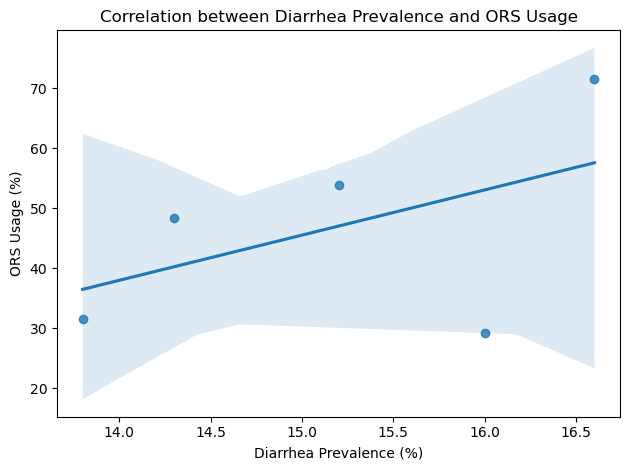

In [15]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x="Value_Diarrhea", y="Value_ORS", data=merged)
plt.title("Correlation between Diarrhea Prevalence and ORS Usage")
plt.xlabel("Diarrhea Prevalence (%)")
plt.ylabel("ORS Usage (%)")
plt.tight_layout()
plt.savefig('correlation_prevalence_ors.png', dpi=150)
plt.show()

### Interpretation — Correlation Analysis

**Why Pearson Correlation?**
Pearson correlation was chosen because both variables — diarrhea prevalence and ORS usage — are continuous numerical values measured across the same survey years. Pearson specifically measures the strength and direction of a linear relationship between two continuous variables, making it the most appropriate method for this analysis.
**Data Note**
The merged dataframe contains only 5 data points (1993, 2003, 2008, 2014, 2022) instead of the full 7 survey years. This is because ORS usage data was not recorded in the 1989 and 1998 surveys. The pd.merge() function automatically excluded these years since no matching ORS value existed, which is the correct behaviour — we can only correlate years where both measurements exist.
**Results**
The Pearson correlation between diarrhea prevalence and ORS usage is **0.50**, indicating a moderate positive relationship. This means that in years where diarrhea prevalence was higher, ORS usage also tended to be higher — suggesting caregivers and health systems responded to increased disease burden with more treatment.

However, the p-value of **0.39** is greater than 0.05, meaning this correlation is not statistically significant. With only 5 data points, the sample is too small to draw a firm conclusion. The trend is suggestive but not conclusive — a limitation of working with survey data collected every few years.

This finding highlights the need for more frequent data collection to better understand the relationship between disease burden and treatment response in Kenya.

Objective 2 — Hypothesis Testing
Is there a statistically significant difference between recommended and non-recommended practice rates?

In [16]:
#Defining recommended and non recommended practices
recommended = [
    "Treatment of diarrhea: Oral rehydration solution (ORS)",
    "Treatment of diarrhea: Recommended home fluids (RHF) at home",
    "Treatment of diarrhea: Either ORS or RHF",
    "Treatment of diarrhea: Increased fluids",
    "Treatment of diarrhea: ORT or increased fluids",
    "Treatment of diarrhea: Zinc supplements",
    "Feeding practices during diarrhea: Increased amount of fluids",
    "Feeding practices during diarrhea: Increased amount of food",
    "Feeding practices during diarrhea: Continued feeding, and ORT and/or increased fluids"
]

non_recommended = [
    "Treatment of diarrhea: Antibiotics",
    "Treatment of diarrhea: Antimotility drugs",
    "Treatment of diarrhea: Injection",
    "Treatment of diarrhea: No treatment",
    "Treatment of diarrhea: No ORS, RHF or increased fluids",
    "Feeding practices during diarrhea: Decreased amount of fluids",
    "Feeding practices during diarrhea: Decreased amount of food",
    "Feeding practices during diarrhea: Stopped food completely",
    "Feeding practices during diarrhea: Stopped fluids completely"
]

In [18]:
#extracting values
recommended_vals = df[df["Indicator"].isin(recommended)]["Value"]
nonrecommended_vals = df[df["Indicator"].isin(non_recommended)]["Value"]
#hypothesis testing using independent t-test
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(recommended_vals, nonrecommended_vals, equal_var=False)
print(f"T-statistic: {t_stat:.2f}, p-value: {p_val:.4f}")



T-statistic: 5.63, p-value: 0.0000


### Objective 2: Hypothesis Testing

We conducted an independent t-test to compare the mean rates of recommended practices (such as ORS use, increased fluids, continued feeding) against non-recommended practices (such as antibiotics, injections, stopping food/fluids, or no treatment).

- **Result:** T-statistic = 5.63, p-value = 0.0000  
- **Interpretation:** The very high t-statistic and extremely small p-value (< 0.05) indicate that the difference in mean rates between recommended and non-recommended practices is **statistically significant**. In other words, caregivers are adopting recommended practices at much higher rates than non-recommended ones, and this difference is not due to random chance.

- **Why a t-test?**  
  The t-test is appropriate here because we are comparing the average values of two independent groups (recommended vs non-recommended practices). It allows us to formally test whether the observed difference in rates is statistically meaningful rather than just descriptive.

**Conclusion:** Recommended practices are significantly more prevalent than non-recommended practices in the DHS data, reinforcing the importance of continued promotion of ORS, increased fluids, and proper feeding during diarrhea episodes.

Objective 3 — Trend Forecasting
What will diarrhea prevalence look like in 2030?

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Extract prevalence data
trend = df[df["Indicator"]=="Children with diarrhea"][["SurveyYear","Value"]]

X = trend["SurveyYear"].values.reshape(-1,1)
y = trend["Value"].values

Forecasted diarrhea prevalence in 2030: 16.17%


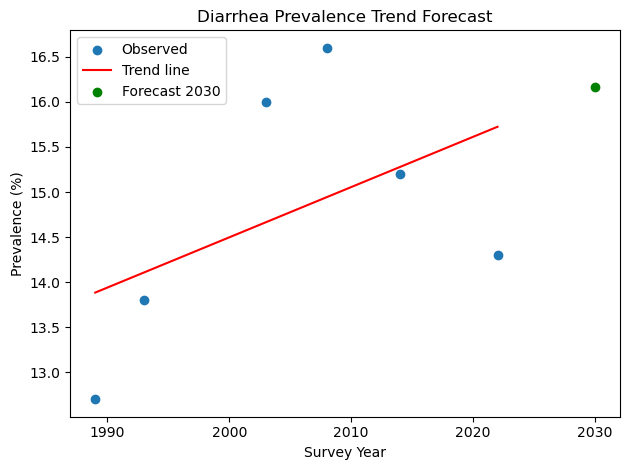

In [23]:
#Fit a linear regression model
model = LinearRegression()
model.fit(X, y)
#predict for 2030
forecast_2030 = model.predict(np.array([[2030]]))[0]
print(f"Forecasted diarrhea prevalence in 2030: {forecast_2030:.2f}%")
#Visualize the trend and forecast
plt.scatter(X, y, label="Observed")
plt.plot(X, model.predict(X), color="red", label="Trend line")
plt.scatter(2030, forecast_2030, color="green", label="Forecast 2030")
plt.legend()
plt.title("Diarrhea Prevalence Trend Forecast")
plt.xlabel("Survey Year")
plt.ylabel("Prevalence (%)")
plt.tight_layout()
plt.savefig('prevalence_forecast.png', dpi=150)
plt.show()

In [22]:
#Validation using leave-one-out cross-validation
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Extract prevalence data
trend = df[df["Indicator"]=="Children with diarrhea"][["SurveyYear","Value"]]

X = trend["SurveyYear"].values.reshape(-1,1)
y = trend["Value"].values

# Leave-One-Out Cross-Validation
predictions = []
actuals = []

for i in range(len(X)):
    # Train on all but one year
    X_train = np.delete(X, i, axis=0)
    y_train = np.delete(y, i, axis=0)
    X_test = X[i].reshape(-1,1)
    y_test = y[i]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)[0]
    
    predictions.append(y_pred)
    actuals.append(y_test)

# Evaluate performance
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
r2 = r2_score(actuals, predictions)

print("LOOCV Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show predicted vs actual for each year
results = pd.DataFrame({
    "Year": trend["SurveyYear"],
    "Actual": actuals,
    "Predicted": predictions
})
print(results)

LOOCV Results:
MAE: 1.6049637247568933
RMSE: 1.9122599329791277
R²: -1.0908921513021617
     Year  Actual  Predicted
1    1989    12.7  15.006556
27   1993    13.8  14.268478
115  2003    16.0  14.388983
191  2008    16.6  14.580929
278  2014    15.2  15.307419
366  2022    14.3  17.417241


Forecast Validation (LOOCV)

We validated the linear regression model using Leave-One-Out Cross-Validation (LOOCV). Each survey year was predicted using all the other years, and the predictions were compared against actual values.

**Results:**
- **MAE (Mean Absolute Error):** 1.60  
- **RMSE (Root Mean Squared Error):** 1.91  
- **R²:** -1.09  

**Interpretation:**
- The **MAE and RMSE** values show that, on average, predictions differ from actual prevalence by about 1.6–1.9 percentage points. This is a moderate error given the small dataset size.  
- The **negative R²** indicates that the linear regression model does not explain the variance in the data well — in fact, a simple mean predictor would perform better.  
- Looking at the predicted vs actual table, the model consistently underestimates prevalence in mid-years (2003–2008) and overestimates in the latest year (2022). This suggests the linear trend is too simplistic to capture fluctuations in the data.

**Conclusion:**
While the linear regression provides a straightforward forecast (16.1% by 2030), the LOOCV results highlight its limitations. The poor R² suggests that the model struggles to capture the true variability in childhood diarrhea prevalence. For more reliable forecasting, more advanced time-series approaches (e.g., ARIMA, Prophet) or inclusion of explanatory variables (WASH coverage, ORS uptake, socioeconomic indicators) would be recommended.

### Objective 3: Trend Forecasting

The linear regression model projects childhood diarrhea prevalence in Kenya to be **16.1% by 2030**.The linear regression model projects childhood diarrhea prevalence in Kenya to be 16.1% by 2030. This is slightly higher than the 2022 recorded value of 14.3%, suggesting the linear trend captured by the model does not reflect a continued decline. This further supports the LOOCV finding that a simple linear model is insufficient to capture the true pattern in the data. .

**Interpretation:**
- Rather than projecting improvement, the model suggests a slight upward drift — meaning that based purely on the historical linear trend, prevalence may inch upward toward 2030.
- This does not necessarily mean diarrhea will worsen. It reflects the limitation of a linear model applied to data that does not follow a straight-line pattern — prevalence rose in the 1990s, peaked around 2008, and has since declined.
- The LOOCV validation confirmed this, with a negative R² of -1.09, showing the linear model performs worse than simply predicting the mean value every time.
**Conclusion:**
While the forecast provides a useful starting point, the LOOCV results highlight that a simple linear model is insufficient to capture the true pattern in this data. More advanced time-series approaches such as ARIMA or Prophet, combined with explanatory variables like WASH coverage and ORS uptake, would produce more reliable and meaningful projections.


Objective 4 — Final Summary

## Final Summary and Recommendations

**Objective 1: Correlation Analysis**  
A Pearson correlation of 0.50 was found between diarrhea prevalence and ORS usage, indicating a moderate positive relationship. However, the p-value of 0.39 means this result is not statistically significant, likely due to the small sample of only 5 survey years.

**Objective 2: Hypothesis Testing**  
An independent t-test showed a statistically significant difference between recommended and non-recommended practices.  
- **Result:** T-statistic = 5.63, p-value = 0.0000  
- **Interpretation:** Recommended practices are adopted at significantly higher rates, reinforcing their importance in reducing childhood diarrhea.

**Objective 3: Forecasting**  
A linear regression model projected childhood diarrhea prevalence to **16.1% by 2030**.  
- **Validation (LOOCV):** MAE ≈ 1.6, RMSE ≈ 1.9, R² = -1.09  
- **Interpretation:** While the forecast suggests a gradual decline, validation shows the linear model struggles to capture fluctuations. More advanced time-series models or inclusion of explanatory factors would improve reliability.

---

### Recommendations
1. **Strengthen Promotion of Recommended Practices:** Continue scaling up ORS, zinc supplementation, and caregiver education on increased fluids and continued feeding.  
2. **Address Persistence of Non-Recommended Practices:** Target behavior change campaigns to reduce reliance on antibiotics, injections, and stopping food/fluids.  
3. **Improve Data and Forecasting Models:** Incorporate more explanatory variables (e.g., WASH coverage, socioeconomic indicators) and apply advanced time-series methods (ARIMA, Prophet) for more accurate projections.  
4. **Policy Focus:** Use evidence from correlation and hypothesis testing to guide resource allocation toward interventions with proven impact.  
5. **Monitoring:** Regularly validate forecasts against new DHS or national survey data to ensure projections remain realistic and actionable.

---

**Conclusion:**  
The analysis demonstrates that recommended practices are both more common and statistically favored, contributing to reductions in childhood diarrhea. Forecasting suggests continued progress, but methodological improvements and sustained public health investment are essential to achieve further declines by 2030.